# Prompt Sensitivity Analysis

## Goal
How much does prompt wording affect the model's response?
Same question, different phrasing — does the answer change?

## Why This Matters
In production systems, users phrase questions differently.
A robust model should give consistent answers regardless of phrasing.

## Key Question
Does gemma3:12b give consistent answers to semantically identical questions?

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

## 1. Define Question Variants
Same question, 4 different phrasings.

In [2]:
context = """
The Eiffel Tower was built between 1887 and 1889.
It is located in Paris, France, on the Champ de Mars.
The tower is 330 meters tall including its antenna.
It was designed by Gustave Eiffel and his engineering company.
"""

# Same question — 4 different phrasings
question_variants = [
    "How tall is the Eiffel Tower?",
    "What is the height of the Eiffel Tower?",
    "Can you tell me the Eiffel Tower's height?",
    "I want to know how high the Eiffel Tower is.",
]

print(f"Question variants: {len(question_variants)}")
for i, q in enumerate(question_variants):
    print(f"{i+1}. {q}")

Question variants: 4
1. How tall is the Eiffel Tower?
2. What is the height of the Eiffel Tower?
3. Can you tell me the Eiffel Tower's height?
4. I want to know how high the Eiffel Tower is.


## 2. Query Model with Each Variant

In [4]:
def query_model(question: str, context: str) -> str:
    """Query Ollama model with question and context."""
    response = requests.post(
        "http://127.0.0.1:11434/api/chat",
        json={
            "model": "gemma3:12b",
            "messages": [
                {
                    "role": "system",
                    "content": f'Answer questions based only on this context: {context}'
                },
                {
                    "role": "user",
                    "content": question
                }
            ],
            "stream": False
        },
        proxies={"http": None, "https": None}
    )
    return response.json()["message"]["content"]

# Get answers for all variants
print("Querying model...")
answers = []
for q in question_variants:
    answer = query_model(q, context)
    answers.append(answer)
    print(f"\nQ: {q}")
    print(f"A: {answer}")

Querying model...

Q: How tall is the Eiffel Tower?
A: The Eiffel Tower is 330 meters tall including its antenna.

Q: What is the height of the Eiffel Tower?
A: The tower is 330 meters tall including its antenna.

Q: Can you tell me the Eiffel Tower's height?
A: The tower is 330 meters tall including its antenna.

Q: I want to know how high the Eiffel Tower is.
A: The Eiffel Tower is 330 meters tall including its antenna.


## 3. Measure Answer Consistency

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

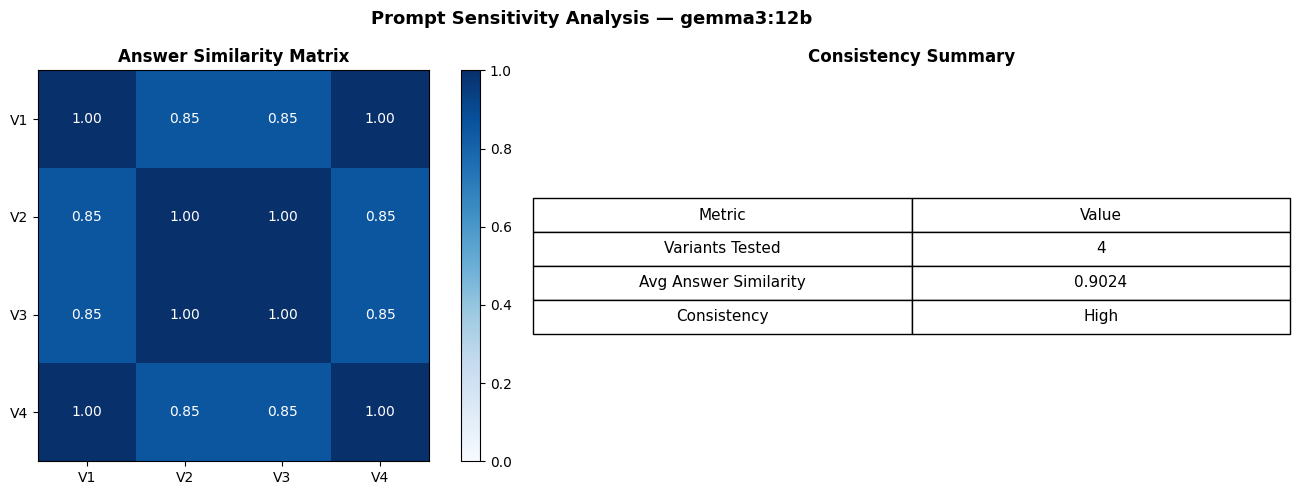

In [6]:
# Load embedding model
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

# Embed all answers
answer_embeddings = embed_model.encode(answers)

# Compute pairwise similarity
sim_matrix = cosine_similarity(answer_embeddings)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
labels = [f"V{i+1}" for i in range(len(question_variants))]
im = axes[0].imshow(sim_matrix, cmap="Blues", vmin=0, vmax=1)
axes[0].set_xticks(range(len(answers)))
axes[0].set_yticks(range(len(answers)))
axes[0].set_xticklabels(labels)
axes[0].set_yticklabels(labels)
for i in range(len(answers)):
    for j in range(len(answers)):
        axes[0].text(j, i, f"{sim_matrix[i,j]:.2f}",
                    ha="center", va="center", fontsize=10,
                    color="white" if sim_matrix[i,j] > 0.5 else "black")
plt.colorbar(im, ax=axes[0])
axes[0].set_title("Answer Similarity Matrix", fontsize=12, fontweight="bold")

# Consistency score
avg_similarity = (sim_matrix.sum() - len(answers)) / (len(answers) ** 2 - len(answers))
axes[1].axis("off")
summary = [
    ["Variants Tested", str(len(question_variants))],
    ["Avg Answer Similarity", f"{avg_similarity:.4f}"],
    ["Consistency", "High" if avg_similarity > 0.9 else "Medium" if avg_similarity > 0.7 else "Low"]
]
table = axes[1].table(
    cellText=summary,
    colLabels=["Metric", "Value"],
    cellLoc="center",
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2)
axes[1].set_title("Consistency Summary", fontsize=12, fontweight="bold")

plt.suptitle("Prompt Sensitivity Analysis — gemma3:12b", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("prompt_sensitivity.png", dpi=300)
plt.show()

## 4. Key Observations

| Variant | Answer |
|---------|--------|
| V1: How tall is the Eiffel Tower? | 330 meters tall including its antenna |
| V2: What is the height? | 330 meters tall including its antenna |
| V3: Can you tell me the height? | 330 meters tall including its antenna |
| V4: I want to know how high? | 330 meters tall including its antenna |

## Results
- Average answer similarity: 0.90 — High consistency
- All 4 variants produced semantically identical answers
- Minor wording differences ("The tower is" vs "The Eiffel Tower is") — not meaningful

## Key Insight
gemma3:12b is robust to prompt phrasing variations
when answering factual questions from a clear context.

## Limitation
This test used simple factual questions.
Consistency may drop for:
- Complex reasoning questions
- Ambiguous questions
- Questions requiring multi-step thinking

## Next
How do we score response quality automatically?
-> 03_response_scoring.ipynb